<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Corpus Linguistics - Study 3 - Phase 1_1 - eyamrog

The aim of this phase is to retrieve data about EL2AP for the dissertation.

## Required Python packages

- pandas
- matplotlib

## Import the required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Define input variables

In [2]:
input_directory = 'cl_st3_ph1_eyamrog'
output_directory = 'cl_st3_ph1_eyamrog'

## Original `EL2AP`

### Import the data into a DataFrame

In [3]:
df_el2ap = pd.read_json(f"{input_directory}/df_el2ap.jsonl", lines=True)

In [4]:
df_el2ap['Submitted'] = pd.to_datetime(df_el2ap['Submitted'], unit='ms')
df_el2ap['Posted'] = pd.to_datetime(df_el2ap['Posted'], unit='ms')

#### Correct the `Discipline` column

In [5]:
discipline_correction_dict = {
    'Linguistic, literature and arts': 'Linguistics, Literature, and Arts'
}

In [6]:
# Correct the 'Discipline' column using the mapping dictionary
df_el2ap['Discipline'] = df_el2ap['Discipline'].replace(discipline_correction_dict)

In [7]:
df_el2ap

,Title,URL,Authors,Published,PDF Language,PDF URL,Submitted,Posted,Text ID,Discipline,Section,Paragraph,Text Paragraph,Text Paragraph ChatGPT
0,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Biological Sciences,Abstract,Paragraph 1,"(Fern flora of Viçosa, Minas Gerais State, Bra...",As part of an ongoing project focused on the f...
1,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Biological Sciences,"Introduction, Literature Review",Paragraph 1,At the end of the era in which the plant Class...,At the end of the period when plant classifica...
2,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Biological Sciences,"Introduction, Literature Review",Paragraph 2,Brazil is represented by Dennstaedtiaceae with...,"In Brazil, Dennstaedtiaceae is represented by ..."
3,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Biological Sciences,"Introduction, Literature Review",Paragraph 3,Pteridium is spread all across the globe (exce...,"Pteridium is distributed globally, with the ex..."
4,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Biological Sciences,"Introduction, Literature Review",Paragraph 4,"In the State of Minas Gerais, Dennstaedtiaceae...","In the state of Minas Gerais, the family Denns..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11131,COVID-19 in Brazil: advantages of a socialized...,https://preprints.scielo.org/index.php/scielo/...,"Julio Croda, Wanderson Kleber de Oliveira, Ro...",Submitted 04/06/2020 - Posted 04/08/2020,PDF,https://preprints.scielo.org/index.php/scielo/...,2020-04-06,2020-04-08,t000315,Health Sciences,"Literature Review, Methodology, Results, Discu...",Paragraph 14,"During the Zika epidemic, Brazil led the disco...","During the Zika epidemic, Brazil was the first..."
11132,COVID-19 in Brazil: advantages of a socialized...,https://preprints.scielo.org/index.php/scielo/...,"Julio Croda, Wanderson Kleber de Oliveira, Ro...",Submitted 04/06/2020 - Posted 04/08/2020,PDF,https://preprints.scielo.org/index.php/scielo/...,2020-04-06,2020-04-08,t000315,Health Sciences,"Literature Review, Methodology, Results, Discu...",Paragraph 15,Although Brazil is attempting to implement mea...,Although Brazil is implementing measures to re...
11133,COVID-19 in Brazil: advantages of a socialized...,https://preprints.scielo.org/index.php/scielo/...,"Julio Croda, Wanderson Kleber de Oliveira, Ro...",Submitted 04/06/2020 - Posted 04/08/2020,PDF,https://preprints.scielo.org/index.php/scielo/...,2020-04-06,2020-04-08,t000315,Health Sciences,"Literature Review, Methodology, Results, Discu...",Paragraph 16,"Regarding cultural differences, the use of mas...","With respect to cultural differences, the use ..."
11134,COVID-19 in Brazil: advantages of a socialized...,https://preprints.scielo.org/index.php/scielo/...,"Julio Croda, Wanderson Kleber de Oliveira, Ro...",Submitted 04/06/2020 - Posted 04/0

### Quantify the articles according to their discipline

In [8]:
# Remove duplicate (Text ID, Discipline) pairs to count unique texts per discipline
df_unique = df_el2ap.drop_duplicates(subset=['Text ID', 'Discipline'])

# Count occurrences of each unique discipline (the values are automatically sorted in descending order)
df_discipline_counts = df_unique['Discipline'].value_counts().reset_index()

# Rename columns
df_discipline_counts.columns = ['Discipline', 'Number of Texts']

# Display the final DataFrame
df_discipline_counts

,Discipline,Number of Texts
0,Health Sciences,186
1,Biological Sciences,50
2,Human Sciences,27
3,Applied Social Sciences,24
4,"Linguistics, Literature, and Arts",15
5,Engineering,6
6,Exact and Earth Sciences,5
7,Agricultural Sciences,3


In [9]:
df_discipline_counts.dtypes

Discipline         object
Number of Texts     int64
dtype: object

### Plot a bar chat

In [10]:
x_label = 'Discipline'
y_label = 'Number of Texts'
title = 'Original EL2AP - Number of Texts per Discipline'
filename = 'df_el2ap_texts_per_discipline'
plot_filename = f"{filename}.png"

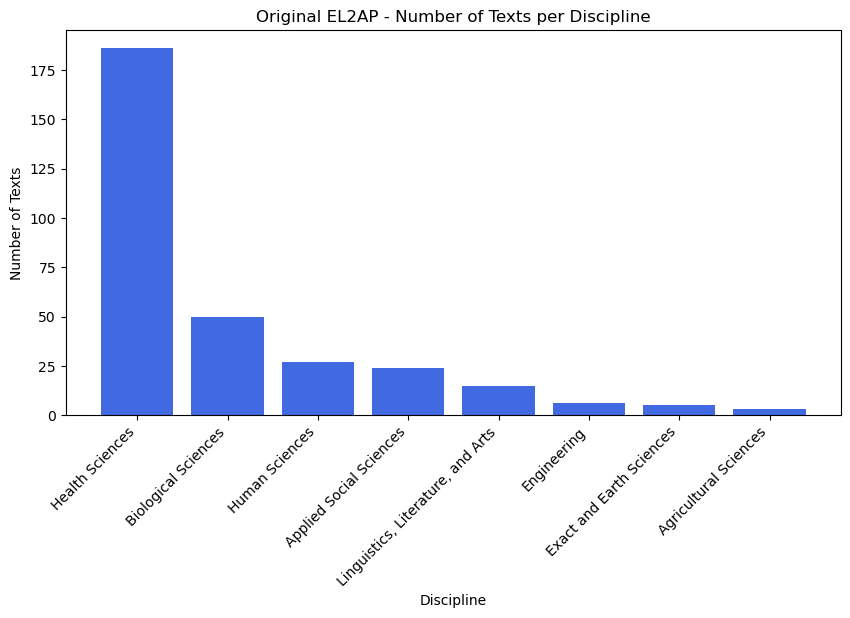

In [11]:
# Plot a bar chart
plt.figure(figsize=(10, 5))  # Adjust figure size
plt.bar(df_discipline_counts['Discipline'], df_discipline_counts['Number of Texts'], color='royalblue')

# Formatting
plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)

# Saving as an image
plt.savefig(f"{output_directory}/{plot_filename}", dpi=300, bbox_inches="tight")

# Show plot
plt.show()

### Create a LaTeX table

In [12]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [13]:
tex_table = df_discipline_counts.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)
# Use the following line for DataFrames with data types 'float64'
#tex_table = df_discipline_counts.to_latex(index=False, float_format='%.2f', longtable=True, decimal=',', caption=caption, label=label)

In [14]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

## Original `EL2AP` - Translate into Brazilian Portuguese

### Import the data into a DataFrame

In [15]:
df_el2ap = pd.read_json(f"{input_directory}/df_el2ap.jsonl", lines=True)

In [16]:
df_el2ap['Submitted'] = pd.to_datetime(df_el2ap['Submitted'], unit='ms')
df_el2ap['Posted'] = pd.to_datetime(df_el2ap['Posted'], unit='ms')

#### Correct the `Discipline` column and translate it

In [17]:
discipline_correction_dict = {
    'Linguistic, literature and arts': 'Linguistics, Literature, and Arts'
}

In [18]:
# Correct the 'Discipline' column using the mapping dictionary
df_el2ap['Discipline'] = df_el2ap['Discipline'].replace(discipline_correction_dict)

In [19]:
discipline_ptbr_dict = {
    'Exact and Earth Sciences': 'Ciências Exatas e da Terra',
    'Biological Sciences': 'Ciências Biológicas',
    'Engineering': 'Engenharias',
    'Health Sciences': 'Ciências da Saúde',
    'Agricultural Sciences': 'Ciências Agrárias',
    'Applied Social Sciences': 'Ciências Sociais Aplicadas',
    'Human Sciences': 'Ciências Humanas',
    'Linguistics, Literature, and Arts': 'Linguística, Letras, e Artes'
}

In [20]:
# Correct the 'Discipline' column using the mapping dictionary
df_el2ap['Discipline'] = df_el2ap['Discipline'].replace(discipline_ptbr_dict)

In [21]:
df_el2ap

,Title,URL,Authors,Published,PDF Language,PDF URL,Submitted,Posted,Text ID,Discipline,Section,Paragraph,Text Paragraph,Text Paragraph ChatGPT
0,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Ciências Biológicas,Abstract,Paragraph 1,"(Fern flora of Viçosa, Minas Gerais State, Bra...",As part of an ongoing project focused on the f...
1,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Ciências Biológicas,"Introduction, Literature Review",Paragraph 1,At the end of the era in which the plant Class...,At the end of the period when plant classifica...
2,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Ciências Biológicas,"Introduction, Literature Review",Paragraph 2,Brazil is represented by Dennstaedtiaceae with...,"In Brazil, Dennstaedtiaceae is represented by ..."
3,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Ciências Biológicas,"Introduction, Literature Review",Paragraph 3,Pteridium is spread all across the globe (exce...,"Pteridium is distributed globally, with the ex..."
4,"(Fern flora of Viçosa, Minas Gerais State, Bra...",https://preprints.scielo.org/index.php/scielo/...,"Nelson Túlio Lage Pena, Pedro Bond Schwartsburd",Submitted 11/22/2022 - Posted 11/23/2022,PDF,https://preprints.scielo.org/index.php/scielo/...,2022-11-22,2022-11-23,t000000,Ciências Biológicas,"Introduction, Literature Review",Paragraph 4,"In the State of Minas Gerais, Dennstaedtiaceae...","In the state of Minas Gerais, the family Denns..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11131,COVID-19 in Brazil: advantages of a socialized...,https://preprints.scielo.org/index.php/scielo/...,"Julio Croda, Wanderson Kleber de Oliveira, Ro...",Submitted 04/06/2020 - Posted 04/08/2020,PDF,https://preprints.scielo.org/index.php/scielo/...,2020-04-06,2020-04-08,t000315,Ciências da Saúde,"Literature Review, Methodology, Results, Discu...",Paragraph 14,"During the Zika epidemic, Brazil led the disco...","During the Zika epidemic, Brazil was the first..."
11132,COVID-19 in Brazil: advantages of a socialized...,https://preprints.scielo.org/index.php/scielo/...,"Julio Croda, Wanderson Kleber de Oliveira, Ro...",Submitted 04/06/2020 - Posted 04/08/2020,PDF,https://preprints.scielo.org/index.php/scielo/...,2020-04-06,2020-04-08,t000315,Ciências da Saúde,"Literature Review, Methodology, Results, Discu...",Paragraph 15,Although Brazil is attempting to implement mea...,Although Brazil is implementing measures to re...
11133,COVID-19 in Brazil: advantages of a socialized...,https://preprints.scielo.org/index.php/scielo/...,"Julio Croda, Wanderson Kleber de Oliveira, Ro...",Submitted 04/06/2020 - Posted 04/08/2020,PDF,https://preprints.scielo.org/index.php/scielo/...,2020-04-06,2020-04-08,t000315,Ciências da Saúde,"Literature Review, Methodology, Results, Discu...",Paragraph 16,"Regarding cultural differences, the use of mas...","With respect to cultural differences, the use ..."
11134,COVID-19 in Brazil: advantages of a socialized...,https://preprints.scielo.org/index.php/scielo/...,"Julio Croda, Wanderson Kleber de Oliveira, Ro...",Submitted 04/06/2020 - Poste

### Quantify the articles according to their discipline

In [22]:
# Remove duplicate (Text ID, Discipline) pairs to count unique texts per discipline
df_unique = df_el2ap.drop_duplicates(subset=['Text ID', 'Discipline'])

# Count occurrences of each unique discipline (the values are automatically sorted in descending order)
df_discipline_counts = df_unique['Discipline'].value_counts().reset_index()

# Rename columns
df_discipline_counts.columns = ['Disciplina', 'Número de Textos']

# Display the final DataFrame
df_discipline_counts

,Disciplina,Número de Textos
0,Ciências da Saúde,186
1,Ciências Biológicas,50
2,Ciências Humanas,27
3,Ciências Sociais Aplicadas,24
4,"Linguística, Letras, e Artes",15
5,Engenharias,6
6,Ciências Exatas e da Terra,5
7,Ciências Agrárias,3


In [23]:
df_discipline_counts.dtypes

Disciplina          object
Número de Textos     int64
dtype: object

### Plot a bar chat

In [24]:
x_label = 'Disciplina'
y_label = 'Número de Textos'
title = 'EL2AP Original - Número de Textos por Disciplina'
filename = 'df_el2ap_texts_per_discipline_ptbr'
plot_filename = f"{filename}.png"

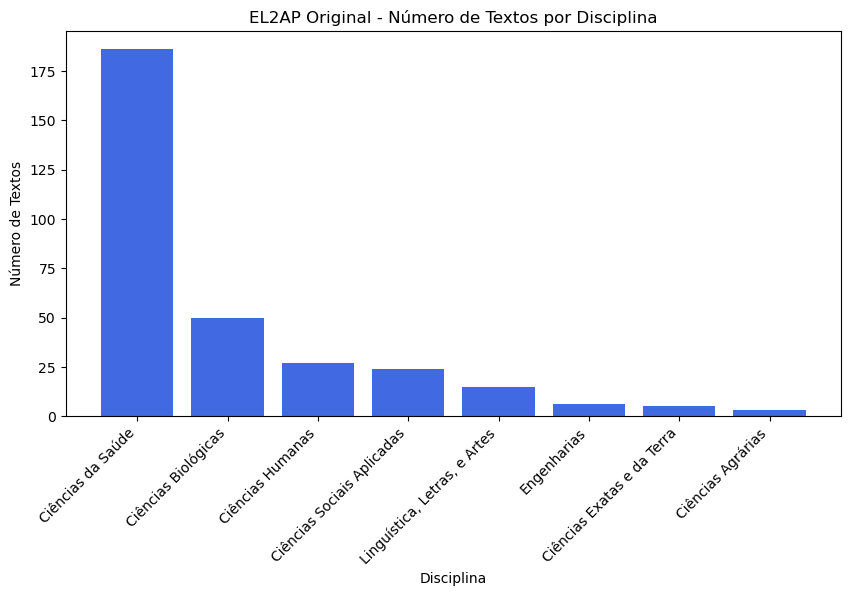

In [25]:
# Plot a bar chart
plt.figure(figsize=(10, 5))  # Adjust figure size
plt.bar(df_discipline_counts['Disciplina'], df_discipline_counts['Número de Textos'], color='royalblue')

# Formatting
plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)

# Saving as an image
plt.savefig(f"{output_directory}/{plot_filename}", dpi=300, bbox_inches="tight")

# Show plot
plt.show()

### Create a LaTeX table

In [26]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [27]:
tex_table = df_discipline_counts.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)
# Use the following line for DataFrames with data types 'float64'
#tex_table = df_discipline_counts.to_latex(index=False, float_format='%.2f', longtable=True, decimal=',', caption=caption, label=label)

In [28]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

## Final `EL2AP`

### Import the data into a DataFrame

In [29]:
df_el2ap_balanced = pd.read_json(f"{output_directory}/df_el2ap_balanced.jsonl", lines=True)

In [30]:
df_el2ap_balanced['Submitted'] = pd.to_datetime(df_el2ap_balanced['Submitted'], unit='ms')
df_el2ap_balanced['Posted'] = pd.to_datetime(df_el2ap_balanced['Posted'], unit='ms')

### Reassess the balance

In [31]:
# Group by 'Discipline' and calculate the required metrics
df_balancing = df_el2ap_balanced.groupby('Discipline').agg(
    Text_Counts=('Text ID', lambda x: x.nunique()),  # Count unique Text IDs
    Paragraph_Counts=('Text ID', 'size')  # Count number of paragraphs (rows)
).reset_index()

# Rename the columns
df_balancing.rename(columns={
    'Text_Counts': 'Text Count',
    'Paragraph_Counts': 'Paragraph Count'
}, inplace=True)

# Sort the DataFrame by 'Paragraph Counts' in descending order
df_balancing = df_balancing.sort_values(by='Paragraph Count', ascending=False).reset_index(drop=True)

# Add 'Average Paragraph Count per Text'
df_balancing['Average Paragraph Count per Text'] = df_balancing['Paragraph Count'] / df_balancing['Text Count']

# Add 'Balanced Paragraph Counts' using direct computation with the index
df_balancing['Balanced Paragraph Count'] = df_balancing['Paragraph Count'] * (df_balancing.index + 1)

# Display the DataFrame
df_balancing

,Discipline,Text Count,Paragraph Count,Average Paragraph Count per Text,Balanced Paragraph Count
0,Health Sciences,45,1684,37.422222,1684
1,Biological Sciences,46,1454,31.608696,2908
2,Human Sciences,26,1269,48.807692,3807
3,Applied Social Sciences,21,1231,58.619048,4924
4,"Linguistic, literature and arts",15,1030,68.666667,5150


In [32]:
x_label = 'Discipline'
y_label = 'Paragraph Count'
title = 'Paragraph Count per Discipline 2'
filename = 'df_el2ap_paragraph_count_per_discipline2'
plot_filename = f"{filename}.png"

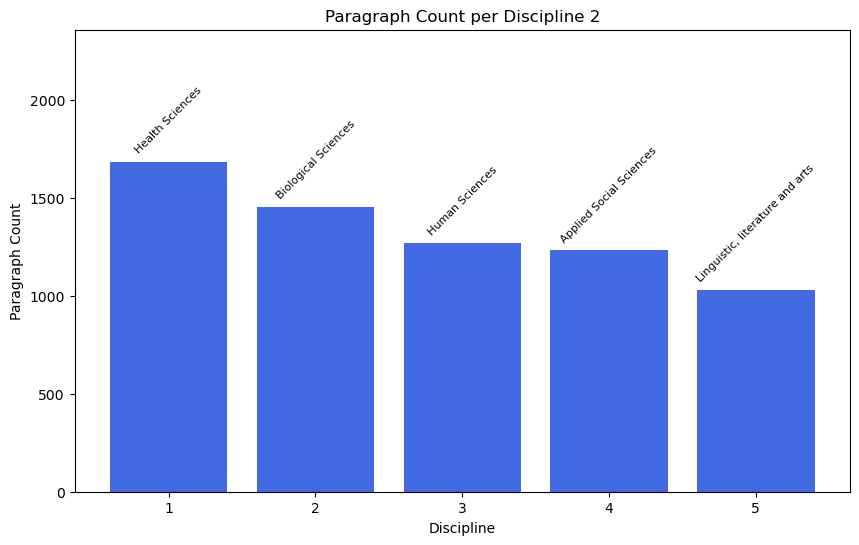

In [33]:
import matplotlib.pyplot as plt

# X-axis: Index + 1
x_axis = df_balancing.index + 1

# Y-axis: Balanced Paragraph Counts
y_axis = df_balancing['Paragraph Count']

# Disciplines for labels
labels = df_balancing['Discipline']

# Plotting the bar plot
plt.figure(figsize=(10, 6))
plt.bar(x_axis, y_axis, color='royalblue')

# Adjust the y-axis range
plt.ylim(0, y_axis.max() * 1.4)  # Extend y-axis to 40% above the maximum value

# Adding labels and title
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(x_axis)  # Ensure all indices are shown

# Adding the labels for each bar
for i, label in enumerate(labels):
    plt.text(x=x_axis[i], y=y_axis[i] + (y_axis.max() * 0.02), s=label, ha='center', va='bottom', fontsize=8, rotation=45)

# Saving as an image
plt.savefig(f"{output_directory}/{plot_filename}", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

### Create a LaTeX table

In [34]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [35]:
tex_table = df_balancing.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [36]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

### Assess the balance of `Paragraph Count` per `Section` per `Discipline`

In [37]:
# Group by 'Section' and 'Discipline' to count the number of paragraphs
df_section_paragraph = df_el2ap_balanced.groupby(['Section', 'Discipline']).size().reset_index(name='Paragraph Count')

# Display the resulting DataFrame
df_section_paragraph

,Section,Discipline,Paragraph Count
0,Abstract,Applied Social Sciences,28
1,Abstract,Biological Sciences,49
2,Abstract,Health Sciences,127
3,Abstract,Human Sciences,32
4,Abstract,"Linguistic, literature and arts",15
...,...,...,...
65,"Results, Discussion",Biological Sciences,164
66,"Results, Discussion",Health Sciences,16
67,"Results, Discussion",Human Sciences,156
68,"Results, Discussion","Linguistic, literature and arts",137


### Create a LaTeX table

In [38]:
title = 'Paragraph Count per Section per Discipline'
filename = 'df_el2ap_paragraph_count_per_section_per_discipline'

In [39]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [40]:
tex_table = df_section_paragraph.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [41]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

## Final `EL2AP` - Translate into Brazilian Portuguese

### Import the data into a DataFrame

In [42]:
df_el2ap_balanced = pd.read_json(f"{output_directory}/df_el2ap_balanced.jsonl", lines=True)

In [43]:
df_el2ap_balanced['Submitted'] = pd.to_datetime(df_el2ap_balanced['Submitted'], unit='ms')
df_el2ap_balanced['Posted'] = pd.to_datetime(df_el2ap_balanced['Posted'], unit='ms')

#### Correct the `Discipline` column and translate it

In [44]:
discipline_correction_dict = {
    'Linguistic, literature and arts': 'Linguistics, Literature, and Arts'
}

In [45]:
# Correct the 'Discipline' column using the mapping dictionary
df_el2ap_balanced['Discipline'] = df_el2ap_balanced['Discipline'].replace(discipline_correction_dict)

In [46]:
discipline_ptbr_dict = {
    'Exact and Earth Sciences': 'Ciências Exatas e da Terra',
    'Biological Sciences': 'Ciências Biológicas',
    'Engineering': 'Engenharias',
    'Health Sciences': 'Ciências da Saúde',
    'Agricultural Sciences': 'Ciências Agrárias',
    'Applied Social Sciences': 'Ciências Sociais Aplicadas',
    'Human Sciences': 'Ciências Humanas',
    'Linguistics, Literature, and Arts': 'Linguística, Letras, e Artes'
}

In [47]:
# Correct the 'Discipline' column using the mapping dictionary
df_el2ap_balanced['Discipline'] = df_el2ap_balanced['Discipline'].replace(discipline_ptbr_dict)

### Reassess the balance

In [48]:
# Group by 'Discipline' and calculate the required metrics
df_balancing = df_el2ap_balanced.groupby('Discipline').agg(
    Text_Counts=('Text ID', lambda x: x.nunique()),  # Count unique Text IDs
    Paragraph_Counts=('Text ID', 'size')  # Count number of paragraphs (rows)
).reset_index()

# Rename the columns
df_balancing.rename(columns={
    'Discipline': 'Disciplina',
    'Text_Counts': 'Contagem de Textos',
    'Paragraph_Counts': 'Contagem de Parágrafos'
}, inplace=True)

# Sort the DataFrame by 'Contagem de Parágrafos' in descending order
df_balancing = df_balancing.sort_values(by='Contagem de Parágrafos', ascending=False).reset_index(drop=True)

# Add 'Contagem Média de Parágrafos por Texto'
df_balancing['Contagem Média de Parágrafos por Texto'] = df_balancing['Contagem de Parágrafos'] / df_balancing['Contagem de Textos']

# Add 'Contagem de Parágrafos Balanceada' using direct computation with the index
df_balancing['Contagem de Parágrafos Balanceada'] = df_balancing['Contagem de Parágrafos'] * (df_balancing.index + 1)

# Display the DataFrame
df_balancing

,Disciplina,Contagem de Textos,Contagem de Parágrafos,Contagem Média de Parágrafos por Texto,Contagem de Parágrafos Balanceada
0,Ciências da Saúde,45,1684,37.422222,1684
1,Ciências Biológicas,46,1454,31.608696,2908
2,Ciências Humanas,26,1269,48.807692,3807
3,Ciências Sociais Aplicadas,21,1231,58.619048,4924
4,"Linguística, Letras, e Artes",15,1030,68.666667,5150


In [49]:
x_label = 'Disciplina'
y_label = 'Contagem de Parágrafos'
title = 'Contagem de Parágrafos por Disciplina 2'
filename = 'df_el2ap_paragraph_count_per_discipline2_ptbr'
plot_filename = f"{filename}.png"

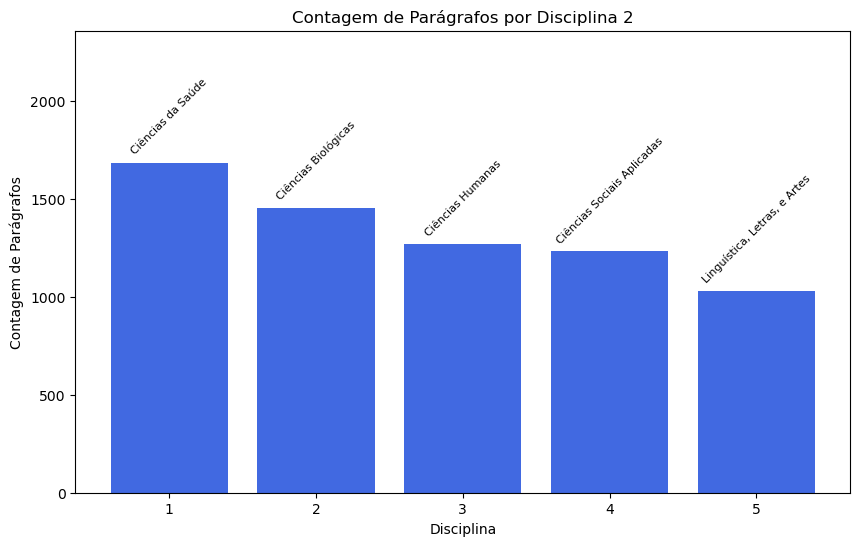

In [50]:
import matplotlib.pyplot as plt

# X-axis: Index + 1
x_axis = df_balancing.index + 1

# Y-axis: Balanced Paragraph Counts
y_axis = df_balancing['Contagem de Parágrafos']

# Disciplines for labels
labels = df_balancing['Disciplina']

# Plotting the bar plot
plt.figure(figsize=(10, 6))
plt.bar(x_axis, y_axis, color='royalblue')

# Adjust the y-axis range
plt.ylim(0, y_axis.max() * 1.4)  # Extend y-axis to 40% above the maximum value

# Adding labels and title
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(x_axis)  # Ensure all indices are shown

# Adding the labels for each bar
for i, label in enumerate(labels):
    plt.text(x=x_axis[i], y=y_axis[i] + (y_axis.max() * 0.02), s=label, ha='center', va='bottom', fontsize=8, rotation=45)

# Saving as an image
plt.savefig(f"{output_directory}/{plot_filename}", dpi=300, bbox_inches="tight")

# Show the plot
plt.show()

### Create a LaTeX table

In [51]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [52]:
tex_table = df_balancing.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [53]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)

### Assess the balance of `Paragraph Count` per `Section` per `Discipline`

In [54]:
# Rename the columns
df_el2ap_balanced.rename(columns={
    'Discipline': 'Disciplina',
    'Section': 'Seção',
    'Text_Counts': 'Contagem de Textos',
    'Paragraph_Counts': 'Contagem de Parágrafos'
}, inplace=True)

# Group by 'Section' and 'Discipline' to count the number of paragraphs
df_section_paragraph = df_el2ap_balanced.groupby(['Seção', 'Disciplina']).size().reset_index(name='Contagem de Parágrafos')

# Display the resulting DataFrame
df_section_paragraph

,Seção,Disciplina,Contagem de Parágrafos
0,Abstract,Ciências Biológicas,49
1,Abstract,Ciências Humanas,32
2,Abstract,Ciências Sociais Aplicadas,28
3,Abstract,Ciências da Saúde,127
4,Abstract,"Linguística, Letras, e Artes",15
...,...,...,...
65,"Results, Discussion",Ciências Humanas,156
66,"Results, Discussion",Ciências Sociais Aplicadas,409
67,"Results, Discussion",Ciências da Saúde,16
68,"Results, Discussion","Linguística, Letras, e Artes",137


### Create a LaTeX table

In [55]:
title = 'Contagem de Parágrafos por Seção por Disciplina'
filename = 'df_el2ap_paragraph_count_per_section_per_discipline_ptbr'

In [56]:
caption = title
label = f"tab:{filename}"
tex_filename = f"{filename}.tex"

In [57]:
tex_table = df_section_paragraph.to_latex(index=False, longtable=True, decimal=',', caption=caption, label=label)

In [58]:
with open(f"{output_directory}/{tex_filename}", 'w', encoding='utf8', newline='\n') as file:
    file.write(tex_table)